 <script src='https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.4/MathJax.js?config=default'></script>



 # Tutorial: POD-ESN model of a 2D cylinder flow



 The aim of a `POD-ESN` object is to create a reduced order model of a dataset (2D velocity fields in this case) by first, performing proper orthogonal decomposition (POD) on the data and then train an echo state network (ESN) to learn the temporal evolution of the POD coefficients.
 The POD-ESN combines **Proper Orthogonal Decomposition (POD)** for spatial compression with an **Echo State Network (ESN)** for temporal forecasting, enabling efficient real-time modelling of high-dimensional flow fields.

 ---

 ### Step 1: Dimensionality Reduction via POD

 The flow field $\mathbf{u}(\mathbf{x}, t) \in \mathbb{R}^{N_u}$ is projected onto the $N_m \ll N_u$ most energetic spatial modes:

 $$\mathbf{u}(\mathbf{x}, t) \approx \boldsymbol{\Psi}(\mathbf{x})\,\boldsymbol{\phi}(t) = \sum_{i=1}^{N_m} \phi_i(t)\, \boldsymbol{\psi}_i(\mathbf{x})$$

 where $\boldsymbol{\Psi} = [\boldsymbol{\psi}_1 \mid \cdots \mid \boldsymbol{\psi}_{N_m}] \in \mathbb{R}^{N_u \times N_m}$ are the POD modes and $\boldsymbol{\phi}(t) \in \mathbb{R}^{N_m}$ are the time-varying POD coefficients. The ESN only needs to model the low-dimensional $\boldsymbol{\phi}(t)$, not the full field.

 ---

 ### Step 2: Temporal Modelling via ESN

 The ESN lifts $\boldsymbol{\phi}_k$ into a high-dimensional **reservoir state** $\mathbf{r}_k \in \mathbb{R}^{N_r}$, with $N_r \gg N_m$, whose dynamics are governed by the **forced dynamical system**

 $$\mathbf{r}_{k+1} = \tanh\!\Big(\underbrace{\sigma_\mathrm{in}\,\mathbf{W}_\mathrm{in}\,\boldsymbol{\phi}_k}_{\text{forcing}} + \underbrace{\rho\,\mathbf{W}\,\mathbf{r}_k}_{\text{memory}}\Big)$$

 where the POD coefficients act as an instantaneous forcing term and the reservoir state carries memory of past dynamics. The forecast POD coefficients are recovered via a **linear readout**:

 $$\hat{\boldsymbol{\phi}}_{k+1} = \mathbf{W}_\mathrm{out}\,\mathbf{r}_{k+1}$$

 The three components of the ESN are:

 - **Input layer** $\mathbf{W}_\mathrm{in} \in \mathbb{R}^{N_r \times N_m}$ — randomly initialised and **fixed**; controlled by the input scaling $\sigma_\mathrm{in}$, which tunes $\tanh$ saturation and nonlinearity

 - **Reservoir** $\mathbf{W} \in \mathbb{R}^{N_r \times N_r}$ (sparse) — randomly initialised and **fixed**; rescaled so its spectral radius equals $\rho < 1$, which controls memory length and ensures the *echo state property* (the influence of past states vanishes gradually)

 - **Readout** $\mathbf{W}_\mathrm{out} \in \mathbb{R}^{N_m \times N_r}$ — the **only trained matrix**, obtained in one shot via ridge regression:

 $$\left(\mathbf{R}\mathbf{R}^\mathrm{T} + \gamma\,\mathbf{I}\right)\mathbf{W}_\mathrm{out}^\mathrm{T} = \mathbf{R}\,\boldsymbol{\Phi}^\mathrm{T}$$

 where  $\boldsymbol{\Phi} \in \mathbb{R}^{N_m \times N}$ contains the training POD coefficients, which projection onto the reservoir is collected in $\mathbf{R} \in \mathbb{R}^{N_r \times N}$, and $\gamma$ is the Tikhonov regularisation parameter. This is a **convex problem with a unique global minimum**.

 <br>

 <br>

 <br>

 <a><img src="../../../docs/figs/DA/ESN-open-close-schematics.png" width=1000px></a>

 We have seen that with 4 modes we reconstruct over 95% of the system's energy, which provides a very small reconstruction RMS. Therefore, we select N_modes = 4 for our reduced order model.


 <br>





 The class `POD-ESN` from `src.models_datadriven` combines two parent classes:

 1. `POD` $\rightarrow$ tutorial `03_Class POD` gives further details on this object.

 2. `ESN_model` $\rightarrow$ tutorial `03_Class ESN_model` gives further details on this object.




 First, let's load and visualize the dataset we will be working with.



In [1]:
from copy import deepcopy

from romda.utils import set_working_directories, load_from_mat_file, get_wake_data
import numpy as np
from romda.utils import animate_flowfields


# Define woking directories
data_folder, results_folder, figs_folder = set_working_directories('wakes')

get_wake_data(data_folder)


# Load dataset
mat = load_from_mat_file(data_folder + '/circle_re_100.mat')

ux = mat['ux']   # (N_t, Nx, Ny) — NaN marks cylinder body interior
uy = mat['uy']

N_t, Nx, Ny = ux.shape
print(f'Snapshots  : N_t = {N_t}')
print(f'Grid       : {Nx} × {Ny}')



File 'circle_re_100.mat' already exists. Skipping download.
File 'README.md' already exists. Skipping download.


Snapshots  : N_t = 800
Grid       : 513 × 129


 ## 1. Data preparation <a name="part1-1"></a>

 - Add noise to the data to mimic PIV measurements.

 - Split the data, i.e., divide the dataset into train and test data

 - Prepare the dataset for dimensionality reduction using

         POD.fit(X):   calls preprocess_snapshot() internally, which:
             - detects the NaN mask (cylinder interior) from the first snapshot
             - flattens fluid points to (N_fluid*Nu, N_t) and subtracts temporal mean
             - stores fluid_mask_flat and grid_shape on the instance


In [2]:
from romda.utils import add_noise_to_flow


# Stack the velocity components together and Split into training and test sets
Nt_train = 100
data_true = np.array([ux, uy])

data_noisy = add_noise_to_flow(data_true, noise_level=0.1, noise_type="gauss", spatial_smooth=0.1)

X_test_true = data_true[:, Nt_train:]
X_train_true = data_true[:, :Nt_train]

X_train = data_noisy[:, :Nt_train]
X_test  = data_noisy[:, Nt_train:]


In [3]:


from IPython.display import HTML

# Visualize the flow fields
datasets = {
    '$u_x$': X_train_true[0].T,
    '$u_x$ noisy': X_train[0].T,
    '$u_y$': X_train_true[1].T,
    '$u_y$ noisy': X_train[1].T,
}
# anim = animate_flowfields(datasets, n_frames=10, step=2, figsize=(8, 6))
# HTML(anim.to_jshtml())


 # Part I. Apply POD to the dataset with `tools.POD` <a name="part1"></a>

 We apply POD to the velocity fielsd $u=[U_x; U_y]$ only because the flow is incompressible. This is because the velocity components carry most of the total kinetic energy (TKE) in a turbulent or unsteady flow.

 The pressure field does not directly contribute to TKE but rather acts as a constraint on the velocity field via the Navier-Stokes equations, specifically $P$ is often computed indirectly from the incompressible constraint ($\nabla\cdot u$) and it exhibits different spatial structures compared to velocity





 ## Initialize POD instance <a name="part1-1"></a>



In [4]:
from romda.models.data_driven import POD

case_pod = POD(n_modes=20, method='exact', domain=[0, 12, -2.5, 2.5])
case_pod.fit(X_train)

print(f'Fitted POD: {case_pod.N_latent} modes retained')
print(f'Psi   : {case_pod.Psi.shape}')
print(f'Phi   : {case_pod.Phi.shape}')
print(f'Sigma : {case_pod.Sigma.shape}')

Fitted POD: 20 modes retained
Psi   : (130644, 20)
Phi   : (20, 100)
Sigma : (20,)


 ## POD eigenvalues and the POD basis <a name="part1-3"></a>

 The eigenvalues contain the kinetic energy of the flow. With only 400 snapshots the POD decomposition is not yet converged as the two lines do not match.

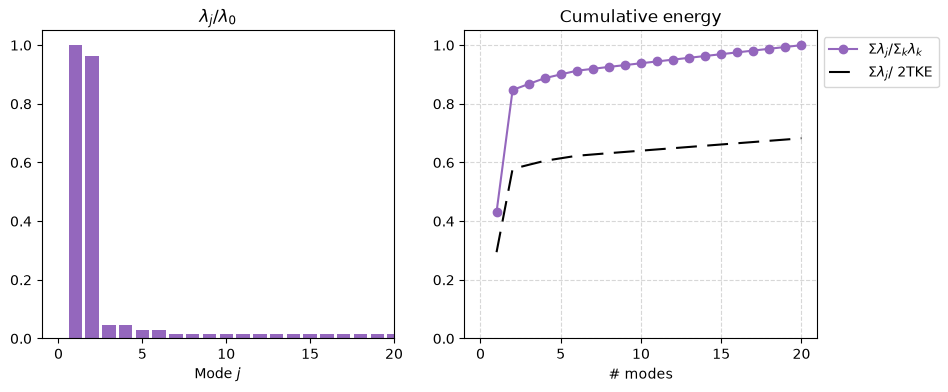

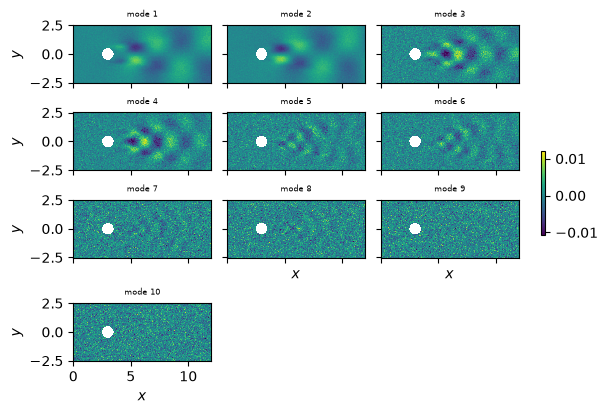

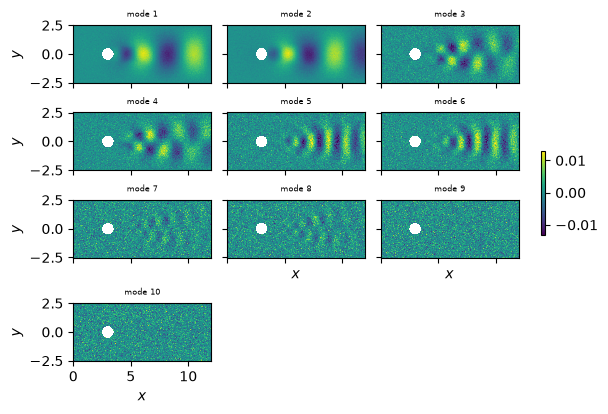

In [5]:
from romda.plotting.pod import plot_spectrum, plot_modes


plot_spectrum(case=case_pod, max_mode=20)
plot_modes(case=case_pod, num_modes=10, n_col=3)



 ## Flow reconstuction <a name="part1-4"></a>



 We can see that most of the energy is concentrated on the first two modes, reaching over 95% of the TKE of the system. Let's now visualize the reconstruction for different number of modes.

In [6]:


N_modes = case_pod.N_latent
X_ref =  X_test[:, -1].copy()  # reference flow field for reconstruction error calculation
X_ref_true = X_test_true[:, -1].copy()

err = np.sqrt((X_ref - X_ref_true)**2) / np.nanmax(np.sqrt(X_ref_true**2))

datasets = {f'Original data': X_ref.copy(),
            'Noise error': err}  # reference data for reconstruction error calculation


    
  

for N_modes in [case_pod.N_latent, 6, 2]:
    # POD case reconstruction
    _case = deepcopy(case_pod).truncate(n_modes=N_modes)

    print(_case.N_latent)

    Q = _case.reconstruct(X_ref.copy())
    X = _case._to_physical_grid(Q)
    


    
    err = np.sqrt((X - X_ref_true)**2) / np.nanmax(np.sqrt(X_ref_true**2))


    datasets[f'{_case.N_latent} modes'] = X.copy()

    datasets[f'Error ({_case.N_latent} modes)'] = err.copy()


    



Requested n_modes=20 >= N_latent=20. No truncation applied.
20
6
2


Displaying dimensions: [0 1]
(2, 513, 129)
Processing dataset 'Original data' with shape (2, 513, 129)...
Processing dataset 'Noise error' with shape (2, 513, 129)...
Processing dataset '20 modes' with shape (2, 513, 129)...
Processing dataset 'Error (20 modes)' with shape (2, 513, 129)...
Processing dataset '6 modes' with shape (2, 513, 129)...
Processing dataset 'Error (6 modes)' with shape (2, 513, 129)...
Processing dataset '2 modes' with shape (2, 513, 129)...
Processing dataset 'Error (2 modes)' with shape (2, 513, 129)...


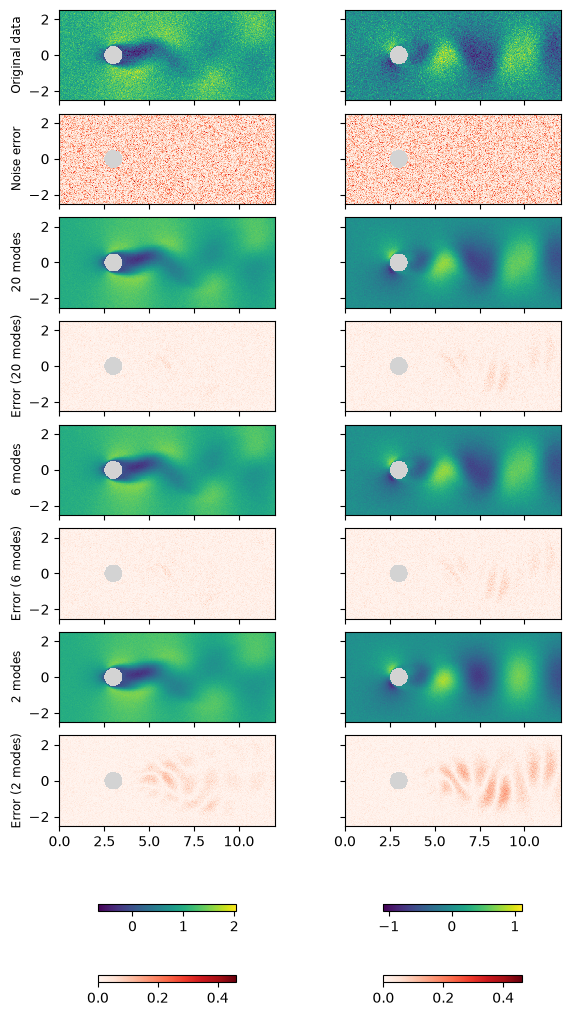

In [7]:
from romda.plotting.pod import plot_flows_rms
plot_flows_rms(case_pod, 
                   datasets=datasets);




 # Part II. Reduced order modelling via POD-ESN from `src.models_datadriven`<a name="part2"></a>








 ## 2. Initilize POD_ESN instance <a name="part2-2"></a>

 - The data provided is used to perform the POD decomposition as well as the ESN training on the POD coefficients.

 - If the flag ```train_ESN=False```, only the POD is perfromed and the ESN is not trained

In [8]:
from romda.models.data_driven import POD_ESN

# help(POD_ESN)  # long output: uncomment for the full docstring


In [9]:
X_train.shape


(2, 100, 513, 129)

Training ESN model...


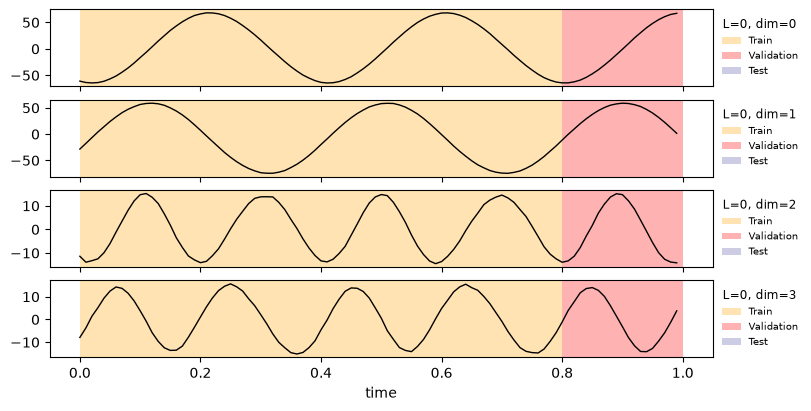

Modifying domain = [0, 12, -2.5, 2.5] -> [0, 12, -2.5, 2.5] at training.

 ----------------- HYPERPARAMETER SEARCH ------------------
 5^2 grid and 1 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 1.000e-02	 1.000e-12	 -1.6543
2	 2.000e-01	 1.000e-01	 1.000e-12	 -1.7823
3	 2.000e-01	 1.000e+00	 1.000e-06	 -1.7633
4	 2.000e-01	 1.000e+01	 1.000e-06	 -1.1545
5	 2.000e-01	 1.000e+02	 1.000e-06	 -0.1888
6	 3.750e-01	 1.000e-02	 1.000e-12	 -1.7846
7	 3.750e-01	 1.000e-01	 1.000e-12	 -1.8323
8	 3.750e-01	 1.000e+00	 1.000e-06	 -1.7988
9	 3.750e-01	 1.000e+01	 1.000e-06	 -1.4307


10	 3.750e-01	 1.000e+02	 1.000e-06	 -0.1289
11	 5.500e-01	 1.000e-02	 1.000e-12	 -1.8933
12	 5.500e-01	 1.000e-01	 1.000e-09	 -1.8551
13	 5.500e-01	 1.000e+00	 1.000e-06	 -1.7899
14	 5.500e-01	 1.000e+01	 1.000e-06	 -1.3839
15	 5.500e-01	 1.000e+02	 1.000e-06	 0.0061
16	 7.250e-01	 1.000e-02	 1.000e-09	 -1.7553
17	 7.250e-01	 1.000e-01	 1.000e-06	 -1.7340
18	 7.250e-01	 1.000e+00	 1.000e-06	 -1.7471
19	 7.250e-01	 1.000e+01	 1.000e-06	 -1.3244
20	 7.250e-01	 1.000e+02	 1.000e-06	 0.0893
21	 9.000e-01	 1.000e-02	 1.000e-09	 -1.3496


22	 9.000e-01	 1.000e-01	 1.000e-06	 -1.3265
23	 9.000e-01	 1.000e+00	 1.000e-06	 -1.7777
24	 9.000e-01	 1.000e+01	 1.000e-12	 -1.4668
25	 9.000e-01	 1.000e+02	 1.000e-06	 0.0596


26	 5.465e-01	 2.648e-02	 1.000e-12	 -1.8399


seed 0 	 Optimal hyperparameters: [np.float64(0.55), np.float64(-2.0)], 1e-12, val score: -1.8933400668988565
trained: 40+10 train+val steps, 0 test | t_train=0.8, t_val=0.2 | rho=0.55, sigma_in=0.01, tikh=1e-12 | 8 validation folds | BHO: 26 evals over ['rho', 'sigma_in']


Displaying dimensions: [0 1]
(2, 513, 129)
Processing dataset 'Input' with shape (2, 513, 129)...
Processing dataset 'POD 4 modes' with shape (2, 513, 129)...
Processing dataset 'Error' with shape (2, 513, 129)...
========= POD-ESN model complete =========


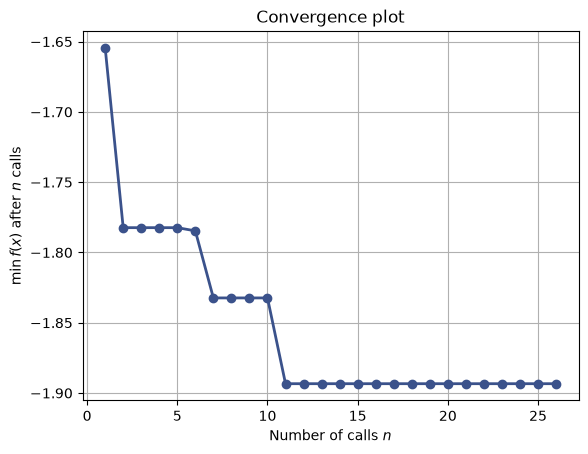

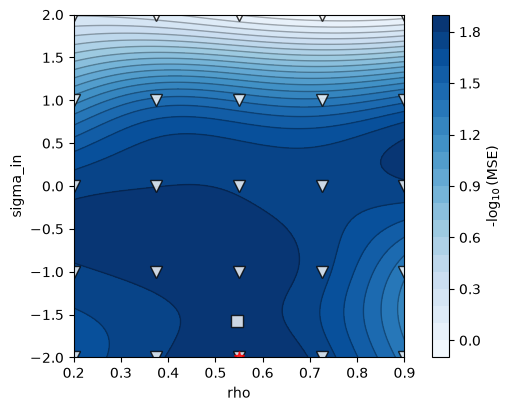

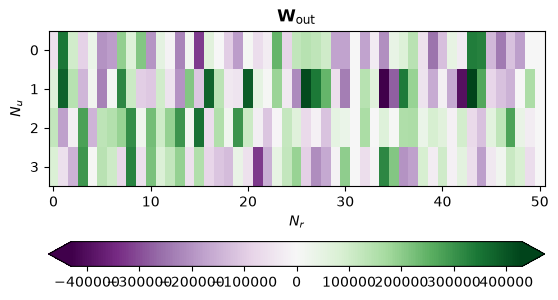

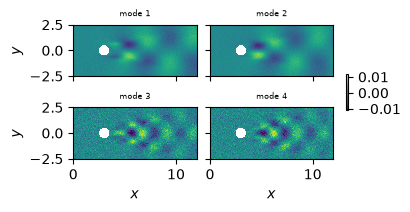

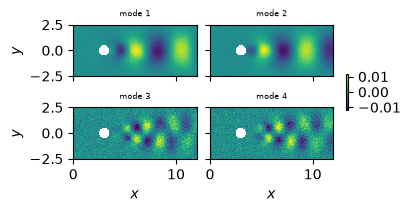

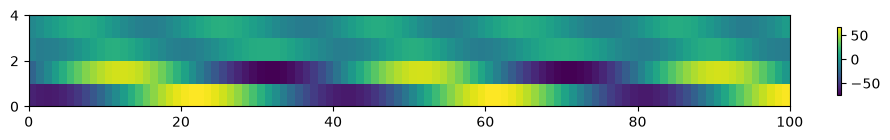

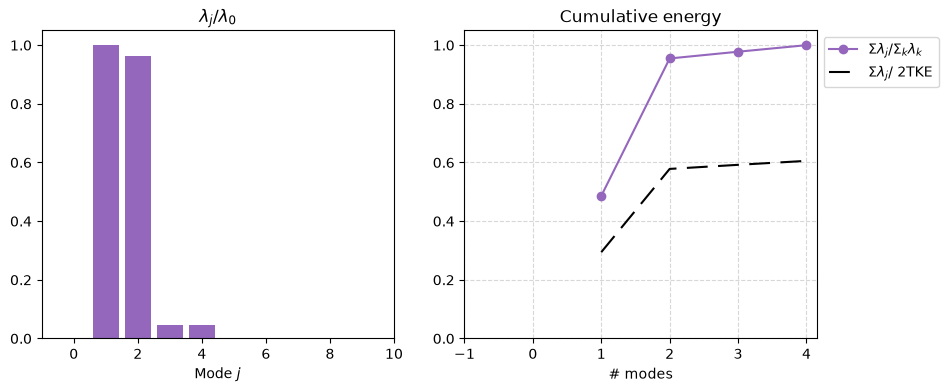

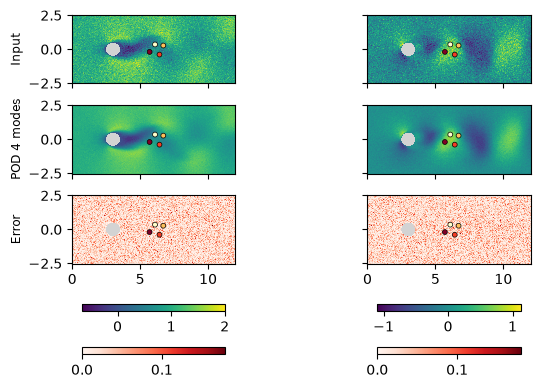

In [10]:
N_train = X_train.shape[1]
dt = 0.01  # time step size

case_ESN = POD_ESN(data=X_train, 
                   dt=dt,
                   n_modes=4, 
                   domain  = [0, 12, -2.5, 2.5],
                   # ====== ESN arguments ======== # 
                   train_ESN=True,
                   t_train=.8* N_train*dt,
                   t_val=.2*N_train*dt,
                   N_wash=10,
                   noise=0.1,
                   N_func_evals=26,
                   rho_range=[0.2, 0.9],
                   upsample=2,
                   perform_test=False,
                   # ====== Plotting flags ======== # 
                   plot_case=True
                  )
case_ESN_og = case_ESN.copy()


 ## 3. Verify implementation <a name="part2-3"></a>

 Check that the POD and POD_ESN cases give the same reconstruction.

 The small diferences are due to the lack of convergence of the POD, as the amount of data used is different.

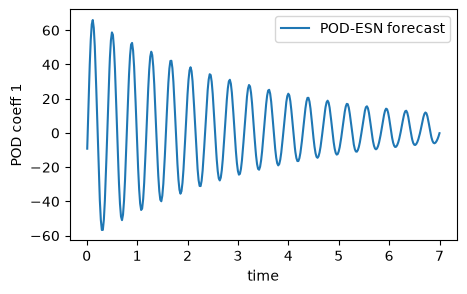

In [11]:
import matplotlib.pyplot as plt

Ntest = X_test.shape[1]
case_ESN = case_ESN_og.copy()

# POD-ESN forecast of the POD coefficients
state, time = case_ESN.time_integrate(Nt=Ntest)
case_ESN.update_history(state, time)

phi = case_ESN.get_POD_coefficients(Nt=Ntest)

plt.figure(figsize=(5, 3))
plt.plot(time, phi[:, 0, 0], label='POD-ESN forecast')
plt.gca().set(xlabel='time', ylabel='POD coeff 1')
plt.legend()

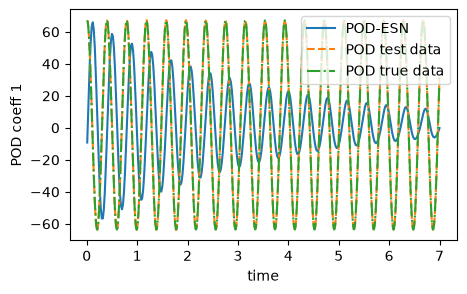

In [12]:
# POD coefficients of the test data (encode handles masking and mean subtraction)
phi_test = case_ESN.encode(X_test)
phi_test_true = case_ESN.encode(X_test_true)

plt.figure(figsize=(5, 3))
plt.plot(time, phi[:, 0, 0], label='POD-ESN')
plt.plot(time, phi_test[0, :len(time)], '--', label='POD test data')
plt.plot(time, phi_test_true[0, :len(time)], '-.', label='POD true data')
plt.gca().set(xlabel='time', ylabel='POD coeff 1')
plt.legend()

 ## 4. Test forecast of the POD-ESN <a name="part2-4"></a>

 We can visualize:

 - The temporal evolution of the POD coefficients

 - The reconstruction of the flow and its MSE

In [13]:
X_test.shape


(2, 700, 513, 129)

In [14]:
# POD coefficients of the noisy and true test data
Phi_true = case_ESN.encode(X_test_true)   # (N_modes, N_test)
Phi_noisy = case_ESN.encode(X_test)       # (N_modes, N_test)

print('POD coefficients:', Phi_true.shape)

POD coefficients: (4, 700)


In [15]:
case_ESN = case_ESN_og.copy()

# === POD-ESN forecast over the test window ===
# The ESN advances at dt_ESN = upsample * dt, so it sees every `upsample`-th test snapshot.
# Open-loop washout on the first N_wash (noisy) test snapshots, then closed loop.
k_ESN = np.arange(0, X_test.shape[1], case_ESN.upsample)   # test snapshots on the ESN time grid
Phi_in = case_ESN.encode(X_test[:, k_ESN]).T                # (N_ESN, N_modes) noisy POD coefficients
n_steps = len(k_ESN) - case_ESN.N_wash

Phi_ESN, _ = case_ESN.closed_loop(Phi_in, n_steps)         # (n_steps, N_modes)
Phi_ESN = Phi_ESN.T                                         # (N_modes, n_steps)

k_fc = k_ESN[case_ESN.N_wash:]                              # test snapshots the forecast lands on
time = k_fc * dt
print(f'Washout: {case_ESN.N_wash} ESN steps; closed loop: {n_steps} steps')

Washout: 10 ESN steps; closed loop: 340 steps


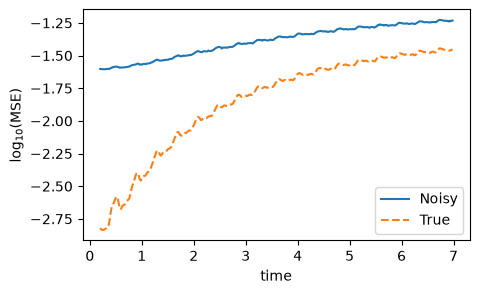

In [16]:
# Compare in the flat zero-mean POD space, on the snapshots the forecast lands on
Q_test = case_ESN.preprocess_snapshot(X_test[:, k_fc])          # (N_x, n_steps)
Q_test_true = case_ESN.preprocess_snapshot(X_test_true[:, k_fc])
Q_pred = case_ESN.decode(Phi_ESN) - case_ESN.Q_mean

MSE_evolution = np.mean((Q_pred - Q_test) ** 2, axis=0)
MSE_evolution_true = np.mean((Q_pred - Q_test_true) ** 2, axis=0)

plt.figure(figsize=(5, 3))
plt.plot(time, np.log10(MSE_evolution))
plt.plot(time, np.log10(MSE_evolution_true), '--')
plt.gca().set(xlabel='time', ylabel='log$_{10}$(MSE)')
plt.legend(['Noisy', 'True'])

In [17]:
# Visualize the flow-field forecast against the test snapshots it lands on
prediction = case_ESN._to_physical_grid(case_ESN.decode(Phi_ESN))  # (Nu, n_steps, Nx, Ny)
truth, noisy = X_test_true[:, k_fc], X_test[:, k_fc]

RMS_noisy = np.sqrt((prediction - noisy) ** 2)
RMS_true = np.sqrt((prediction - truth) ** 2)

# 10 frames spread over the whole closed-loop forecast
frames = np.linspace(0, n_steps - 1, 10).astype(int)

# Keys are the subplot titles ('RMS' titles get the Reds colormap); fields are (Ny, Nx, Nt)
U_datasets = {'Truth':      truth[0, frames].transpose(2, 1, 0),
              'Noisy data': noisy[0, frames].transpose(2, 1, 0),
              'POD-ESN':    prediction[0, frames].transpose(2, 1, 0),
              'RMS noisy':  RMS_noisy[0, frames].transpose(2, 1, 0),
              'RMS true':   RMS_true[0, frames].transpose(2, 1, 0)}

with plt.rc_context({'figure.dpi': 50}):  # low-res frames keep the embedded animation small
    # grid cells are 12/512 streamwise (vertical here) by 5/128 cross-stream
    anim = animate_flowfields(U_datasets, n_frames=len(frames), figsize=(10, 6),
                              aspect=(12 / 512) / (5 / 128))
# anim

In [18]:
HTML(anim.to_jshtml())


 The POD-ESN recovers the true field from a noisy dataset, effectively acting as a de-noiser. Can we achieve this at higher noise levels? How about spatially smoothed or coloured noise?